# Multi-Factor Equity Risk Model

## Objective

This project builds a quantitative equity risk model using the Fama-French
factor framework.

The model estimates each stock's exposure to systematic equity factors,
including:

- Market
- Size
- Value
- Profitability
- Investment

The analysis is then extended to a multi-stock portfolio to evaluate factor
exposures, alpha, idiosyncratic risk, rolling betas, and risk contributions.


In [158]:
!pip install yfinance pandas-datareader -q

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from datetime import date


from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [157]:


tickers = [
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "NVDA",   # Nvidia
    "JPM",    # JPMorgan
    "XOM",    # Exxon Mobil
    "JNJ",    # Johnson & Johnson
    "PG",     # Procter & Gamble
    "HD",     # Home Depot
    "CAT",    # Caterpillar
    "KO"      # Coca-Cola
]

start_date = "2021-01-01"
end_date = date.today()

In [115]:
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

### Calculate Daily Stock Returns

In [116]:
prices = data["Close"]

In [117]:
returns = prices.pct_change().dropna()

### Descriptive Statistics of Stock Returns

Calculate key statistics such as mean daily return, daily volatility, annualized return, and annualized volatility for each stock.

In [118]:
summary_stats = pd.DataFrame({
    "Daily Mean Return": returns.mean(),
    "Daily Volatility": returns.std(),
    "Annualized Return": returns.mean() * 252,
    "Annualized Volatility": returns.std() * np.sqrt(252)
})

### Analyze Return and Volatility Ratios

In [119]:
summary_stats["Return / Volatility"] = (
    summary_stats["Annualized Return"]
    / summary_stats["Annualized Volatility"]
)


### Inter-Stock Correlation Analysis

Compute the correlation matrix of daily stock returns to understand how stock prices move in relation to each other.

In [120]:
correlation_matrix = returns.corr()

### Fetch Fama-French 5-Factor Data

Download the daily Fama-French 5-Factor Research Data from the Kenneth French Data Library. These factors are crucial for the equity risk model.

In [121]:
!pip install pandas-datareader -q

from pandas_datareader import data as web

### Prepare Fama-French Factors

Scale the Fama-French factors (which are typically percentages) to decimal form and align their index with the stock returns data.

In [122]:
ff5 = web.DataReader(
    "F-F_Research_Data_5_Factors_2x3_daily",
    "famafrench",
    start=start_date
)[0]

In [123]:
ff5 = ff5 / 100

### Merge Stock Returns and Fama-French Factors

Combine the stock returns with the Fama-French factors into a single DataFrame for regression analysis.

In [124]:
ff5.index = ff5.index.to_timestamp()
returns.index = pd.to_datetime(returns.index)

### Fama-French Five-Factor Model

The model estimates the sensitivity of each security's excess return to five systematic equity factors:

- Market excess return (Mkt-RF)
- Size (SMB)
- Value (HML)
- Profitability (RMW)
- Investment (CMA)

The estimated model is:

Ri - Rf = α + β1(Mkt-RF) + β2(SMB) + β3(HML) + β4(RMW) + β5(CMA) + ε

In [125]:
model_data = returns.join(ff5, how="inner")

### Run Factor Model for Each Stock

Iterate through each stock and run the Fama-French 5-factor regression to obtain factor exposures and model statistics.

In [126]:
def run_factor_model(ticker, data, factors):
  """
  Runs a Fama-French 5-factor regression for a single stock.

  Returns:
    fitted statsmodels regression object
  """
  # calculate excess return
  y = data[ticker] - data["RF"]

  # select factor returns
  X = data[factors]

  # add intercept for alpha
  X = sm.add_constant(X)

  # run OLS regression
  model = sm.OLS(y, X).fit()

  return model

factor_columns = [
    "Mkt-RF",
    "SMB",
    "HML",
    "RMW",
    "CMA"
]


In [127]:
factor_results = {}

for ticker in tickers:

  model = run_factor_model(ticker, model_data, factor_columns)

  factor_results[ticker] = model

### Create Factor Exposure Table

Compile the estimated factor betas (exposures) for each stock into a comprehensive table, including an annualized alpha.

In [128]:
exposure_table = pd.DataFrame()

for ticker, model in factor_results.items():

    exposure_table[ticker] = model.params

exposure_table = exposure_table.T

### Evaluate Model Fit: R-Squared

Calculate the R-squared for each stock's regression, indicating the proportion of variance in stock returns explained by the Fama-French factors.

In [129]:
exposure_table = exposure_table.rename(
    columns={"const": "Alpha"}
)

### Alpha Significance: T-Statistics and P-Values

Determine the statistical significance of each stock's alpha by computing its t-statistic and p-value.

In [130]:
r_squared = {
    ticker: model.rsquared
    for ticker, model in factor_results.items()
}

exposure_table["R-Squared"] = pd.Series(r_squared)

### Annualize Alpha and Summarize Individual Stock Results

Annualize the alpha and compile a summary table of all individual stock factor exposures, R-squared values, and alpha significance metrics.

In [131]:
exposure_table["Annualized Alpha"] = (
    exposure_table["Alpha"] * 252
)

### compounded version
exposure_table["Annualized Alpha Compounded"] = (
    (1 + exposure_table["Alpha"]) ** 252 - 1
)

In [132]:
alpha_tstats = {}
alpha_pvalues = {}

for ticker, model in factor_results.items():

    alpha_tstats[ticker] = model.tvalues["const"]
    alpha_pvalues[ticker] = model.pvalues["const"]

exposure_table["Alpha T-Stat"] = pd.Series(alpha_tstats)
exposure_table["Alpha P-Value"] = pd.Series(alpha_pvalues)

### Calculate Idiosyncratic Volatility

Compute the annualized idiosyncratic (residual) volatility for each stock, representing the risk not explained by the Fama-French factors.

In [133]:
summary_table = exposure_table[
    [
        "Annualized Alpha Compounded",
        "Mkt-RF",
        "SMB",
        "HML",
        "RMW",
        "CMA",
        "R-Squared",
        "Alpha T-Stat",
        "Alpha P-Value"
    ]
].copy()

summary_table.columns = [
    "Annualized Alpha",
    "Market Beta",
    "Size Beta",
    "Value Beta",
    "Profitability Beta",
    "Investment Beta",
    "R-Squared",
    "Alpha T-Stat",
    "Alpha P-Value"
]

summary_table.round(3)

,Annualized Alpha,Market Beta,Size Beta,Value Beta,Profitability Beta,Investment Beta,R-Squared,Alpha T-Stat,Alpha P-Value
AAPL,0.0410,1.2120,-0.0680,-0.4850,0.5030,0.3900,0.5930,0.5280,0.5980
MSFT,0.0180,1.0180,-0.3060,-0.4120,0.3480,-0.3120,0.6180,0.2570,0.7970
NVDA,0.5570,1.8700,-0.5080,-0.9000,0.0300,-0.0400,0.5860,3.1310,0.0020
JPM,0.0010,1.0480,-0.1590,0.9190,-0.1400,-0.2940,0.5660,0.0160,0.9870
XOM,0.0980,0.7230,-0.1810,0.9390,-0.3090,0.2870,0.3240,0.9650,0.3350
JNJ,0.0490,0.2810,-0.0420,0.1180,0.2220,0.1370,0.0790,0.6800,0.4970
PG,-0.0380,0.4140,-0.0730,-0.0760,0.5080,0.2850,0.1760,-0.5580,0.5770
HD,-0.0100,0.8600,0.5670,-0.1830,0.7330,0.0960,0.4320,-0.1300,0.8960
CAT,0.1770,1.1600,0.2030,0.7700,-0.2050,0.0760,0.4660,1.6880,0.0920
KO,0.0220,0.4100,-0.1180,0.0710,0.3980,0.1860,0.1840,0.3430,0.7320


### Construct an Equal-Weighted Portfolio

Define the portfolio by assigning equal weights to each stock.

In [134]:
residual_volatility = {}

for ticker, model in factor_results.items():

    daily_residual_vol = model.resid.std()

    annual_residual_vol = (
        daily_residual_vol * np.sqrt(252)
    )

    residual_volatility[ticker] = annual_residual_vol

summary_table["Idiosyncratic Volatility"] = pd.Series(
    residual_volatility
)

### Calculate Portfolio Returns

In [135]:
n_stocks = len(tickers)

weights = np.repeat(1 / n_stocks, n_stocks)

### Merge Portfolio Returns and Fama-French Factors

Combine the portfolio's daily returns with the Fama-French factors for portfolio-level regression analysis.

In [136]:
portfolio_returns = returns[tickers].dot(weights)

portfolio_returns.name = "Portfolio"

### Calculate Portfolio Excess Returns

In [137]:
portfolio_data = ff5.join(
    portfolio_returns,
    how="inner"
)

### Run Factor Model for the Portfolio

Execute the Fama-French 5-factor regression for the constructed portfolio to determine its overall factor exposures and alpha.

In [138]:
portfolio_data["Portfolio_Excess"] = (
    portfolio_data["Portfolio"] - portfolio_data["RF"]
)

### Summarize Portfolio Factor Exposures and Performance

Compile a summary of the portfolio's annualized alpha, factor betas, R-squared, and alpha significance.

In [139]:
y_portfolio = portfolio_data["Portfolio_Excess"]

X_portfolio = portfolio_data[
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
]

X_portfolio = sm.add_constant(X_portfolio)

portfolio_model = sm.OLS(
    y_portfolio,
    X_portfolio
).fit()

### Compare Individual Stock Betas to Portfolio Betas

Calculate the weighted average of individual stock betas and compare them to the portfolio's overall betas.

In [140]:
portfolio_summary = {
    "Annualized Alpha":
        (1 + portfolio_model.params["const"])**252 - 1,

    "Market Beta":
        portfolio_model.params["Mkt-RF"],

    "Size Beta":
        portfolio_model.params["SMB"],

    "Value Beta":
        portfolio_model.params["HML"],

    "Profitability Beta":
        portfolio_model.params["RMW"],

    "Investment Beta":
        portfolio_model.params["CMA"],

    "R-Squared":
        portfolio_model.rsquared,

    "Alpha T-Stat":
        portfolio_model.tvalues["const"],

    "Alpha P-Value":
        portfolio_model.pvalues["const"]
}

portfolio_summary = pd.Series(portfolio_summary)

### Calculate Additional Portfolio Performance Metrics

Compute annualized return, annualized volatility, Sharpe ratio, and maximum drawdown for the portfolio.

In [141]:
individual_betas = exposure_table[
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
]

weighted_average_betas = (
    individual_betas.T @ weights
)


### Perform Rolling Regression Analysis

Utilize `RollingOLS` to analyze how factor betas change over time, providing insights into the dynamic nature of factor exposures.

In [142]:
annualized_return = portfolio_returns.mean() * 252

annualized_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)

sharpe_like = (
    annualized_return / annualized_volatility
)

max_drawdown = (
    (
        (1 + portfolio_returns).cumprod()
        /
        (1 + portfolio_returns).cumprod().cummax()
    ) - 1
).min()

portfolio_stats = pd.Series({
    "Annualized Return": annualized_return,
    "Annualized Volatility": annualized_volatility,
    "Return / Volatility": sharpe_like,
    "Maximum Drawdown": max_drawdown
})

### Prepare Data for Rolling Regression

In [143]:
from statsmodels.regression.rolling import RollingOLS

### Fit the Rolling Regression Model

In [144]:
rolling_y = portfolio_data["Portfolio_Excess"]

rolling_X = portfolio_data[
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
]

rolling_X = sm.add_constant(rolling_X)


### Extract Rolling Betas

In [145]:
rolling_model = RollingOLS(
    endog=rolling_y,
    exog=rolling_X,
    window=60
)

rolling_results = rolling_model.fit()

### Extract Current Factor Exposures

Obtain the most recent 60-day factor exposures from the rolling regression results.

In [146]:
rolling_betas = rolling_results.params

rolling_betas = rolling_betas.dropna()

### Compare Full-Period vs. Current Factor Exposures

Contrast the long-term factor exposures with the short-term (60-day) exposures to identify recent shifts in portfolio characteristics.

In [147]:
current_exposures = rolling_betas[
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
].iloc[-1]

### Analyze Beta Stability

Quantify the variability of the rolling betas to assess the stability of factor exposures over time.

In [148]:
full_period_exposures = portfolio_model.params[
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
]

current_exposures = rolling_betas[
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
].iloc[-1]

exposure_comparison = pd.DataFrame({
    "Full Period": full_period_exposures,
    "Current 60-Day": current_exposures
})

### Final Key Performance Indicators (KPIs) for the Portfolio

Compute a comprehensive set of performance and risk metrics for the portfolio, including annualized return, volatility, Sharpe ratio, maximum drawdown, and factor model results.

In [149]:
beta_stability = rolling_betas[
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
].std()

### Visualize Portfolio Dashboard

Generate a dashboard with multiple plots to visualize key aspects of the portfolio's factor exposures, performance, and risk metrics.

In [150]:
# Proper risk-free-rate-adjusted Sharpe ratio
annualized_excess_return = (
    portfolio_data["Portfolio_Excess"].mean() * 252
)

annualized_portfolio_vol = (
    portfolio_data["Portfolio"].std() * np.sqrt(252)
)

sharpe_ratio = (
    annualized_excess_return / annualized_portfolio_vol
)

# Portfolio idiosyncratic volatility
portfolio_idio_vol = (
    portfolio_model.resid.std() * np.sqrt(252)
)

# Maximum drawdown
wealth_index = (1 + portfolio_returns).cumprod()

drawdown = (
    wealth_index / wealth_index.cummax()
) - 1

max_drawdown = drawdown.min()

# Final metrics table
final_metrics = pd.Series({
    "Annualized Return":
        portfolio_returns.mean() * 252,

    "Annualized Volatility":
        annualized_portfolio_vol,

    "Sharpe Ratio":
        sharpe_ratio,

    "Maximum Drawdown":
        max_drawdown,

    "Annualized Alpha":
        (1 + portfolio_model.params["const"])**252 - 1,

    "Market Beta":
        portfolio_model.params["Mkt-RF"],

    "Size Beta":
        portfolio_model.params["SMB"],

    "Value Beta":
        portfolio_model.params["HML"],

    "Profitability Beta":
        portfolio_model.params["RMW"],

    "Investment Beta":
        portfolio_model.params["CMA"],

    "R-Squared":
        portfolio_model.rsquared,

    "Idiosyncratic Volatility":
        portfolio_idio_vol,

    "Alpha T-Statistic":
        portfolio_model.tvalues["const"],

    "Alpha P-Value":
        portfolio_model.pvalues["const"]
})

### Analyze Factor Exposure Changes

Identify which factor exposures have changed most significantly between the full period and the current 60-day period.

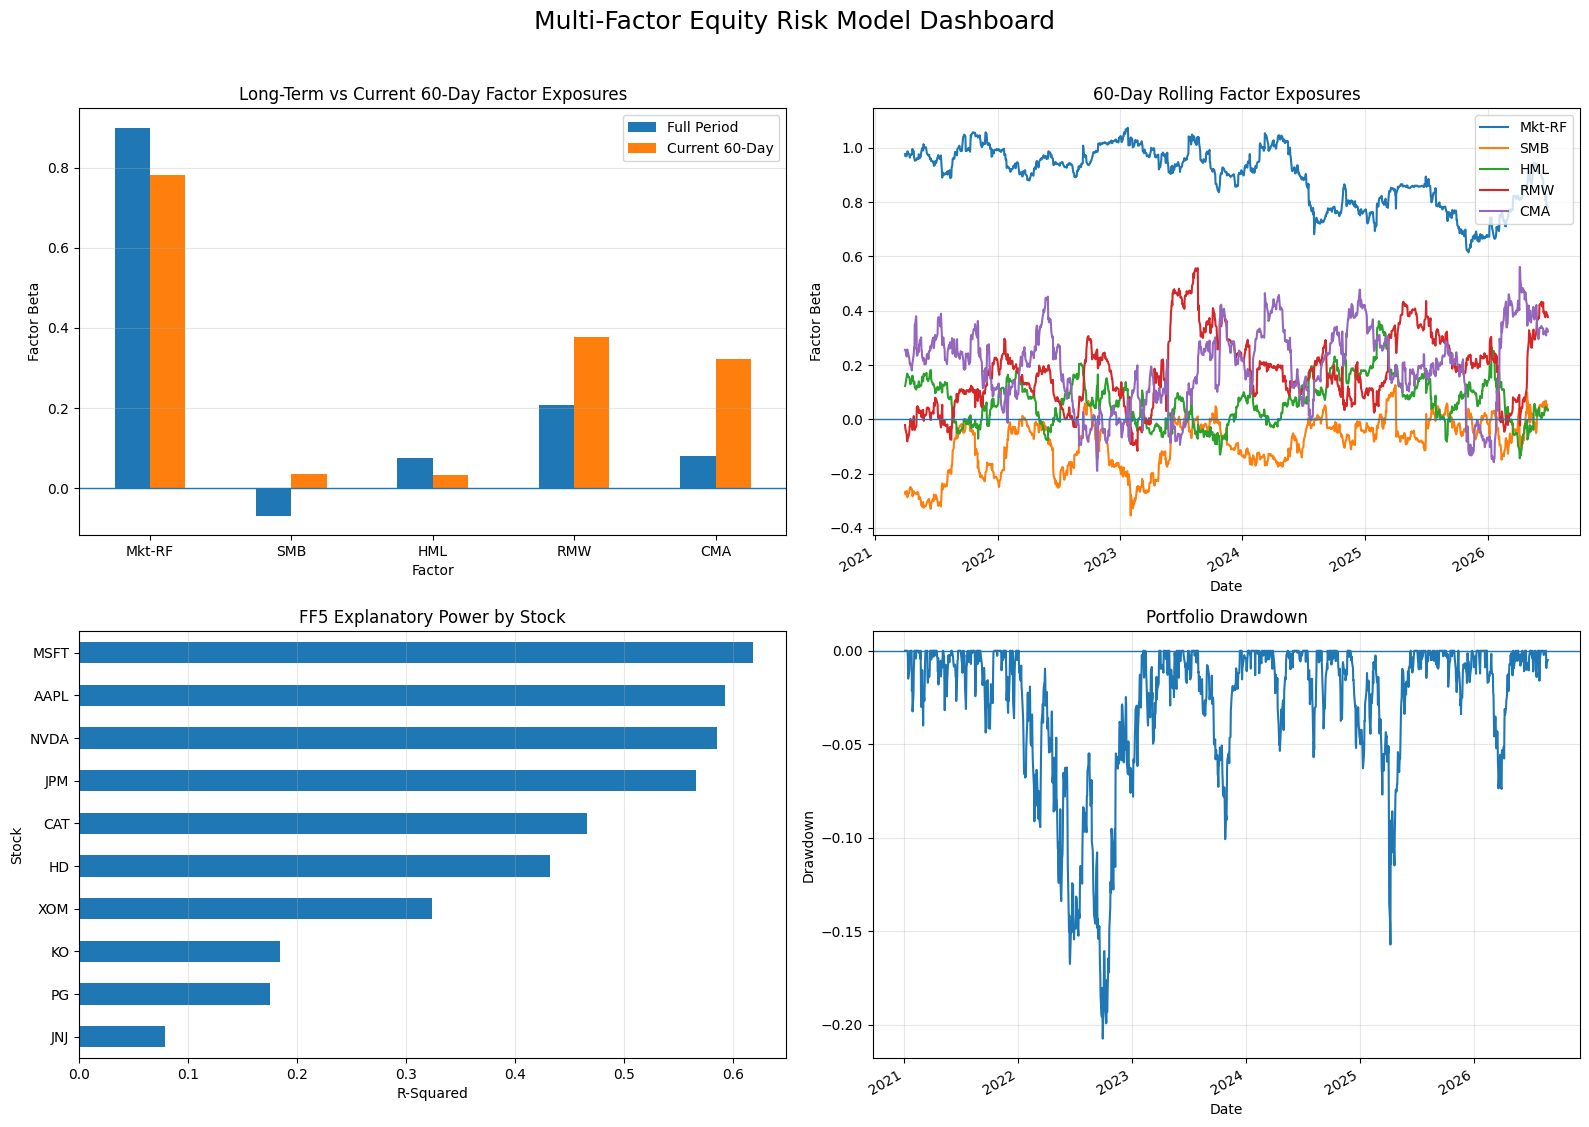

In [151]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

# -----------------------------
# Chart 1: Current vs Long-Term Factor Exposure
# -----------------------------

exposure_comparison.plot(
    kind="bar",
    ax=axes[0, 0]
)

axes[0, 0].axhline(
    0,
    linewidth=1
)

axes[0, 0].set_title(
    "Long-Term vs Current 60-Day Factor Exposures"
)

axes[0, 0].set_ylabel(
    "Factor Beta"
)

axes[0, 0].set_xlabel(
    "Factor"
)

axes[0, 0].tick_params(
    axis="x",
    rotation=0
)

axes[0, 0].grid(
    axis="y",
    alpha=0.3
)


# -----------------------------
# Chart 2: Rolling Factor Betas
# -----------------------------

rolling_betas[
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
].plot(
    ax=axes[0, 1]
)

axes[0, 1].axhline(
    0,
    linewidth=1
)

axes[0, 1].set_title(
    "60-Day Rolling Factor Exposures"
)

axes[0, 1].set_ylabel(
    "Factor Beta"
)

axes[0, 1].set_xlabel(
    "Date"
)

axes[0, 1].grid(
    alpha=0.3
)


# -----------------------------
# Chart 3: Individual Stock R-Squared
# -----------------------------

summary_table[
    "R-Squared"
].sort_values().plot(
    kind="barh",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "FF5 Explanatory Power by Stock"
)

axes[1, 0].set_xlabel(
    "R-Squared"
)

axes[1, 0].set_ylabel(
    "Stock"
)

axes[1, 0].grid(
    axis="x",
    alpha=0.3
)


# -----------------------------
# Chart 4: Portfolio Drawdown
# -----------------------------

drawdown.plot(
    ax=axes[1, 1]
)

axes[1, 1].axhline(
    0,
    linewidth=1
)

axes[1, 1].set_title(
    "Portfolio Drawdown"
)

axes[1, 1].set_ylabel(
    "Drawdown"
)

axes[1, 1].set_xlabel(
    "Date"
)

axes[1, 1].grid(
    alpha=0.3
)


plt.suptitle(
    "Multi-Factor Equity Risk Model Dashboard",
    fontsize=18,
    y=1.02
)

plt.tight_layout()

plt.show()

### Detailed Portfolio Interpretation

Provide a textual interpretation of the portfolio's factor exposures, alpha, and overall fit of the Fama-French model, including insights from the rolling regression.

In [152]:
factor_change = (
    exposure_comparison["Current 60-Day"]
    -
    exposure_comparison["Full Period"]
)

factor_change = factor_change.sort_values(
    key=abs,
    ascending=False
)

### Conclusion

Summarize the key findings from the multi-factor equity risk model analysis for the equal-weighted portfolio.

In [153]:
market_beta = portfolio_model.params["Mkt-RF"]
size_beta = portfolio_model.params["SMB"]
value_beta = portfolio_model.params["HML"]
profit_beta = portfolio_model.params["RMW"]
investment_beta = portfolio_model.params["CMA"]

alpha = (
    (1 + portfolio_model.params["const"])**252 - 1
)

alpha_p = portfolio_model.pvalues["const"]

r_squared = portfolio_model.rsquared

current_market = current_exposures["Mkt-RF"]


# Market interpretation
if market_beta > 1.10:
    market_text = "above-market systematic sensitivity"
elif market_beta < 0.90:
    market_text = "below-market systematic sensitivity"
else:
    market_text = "approximately market-level systematic sensitivity"


# Size interpretation
size_text = (
    "small-cap"
    if size_beta > 0
    else "large-cap"
)


# Value interpretation
value_text = (
    "value"
    if value_beta > 0
    else "growth"
)


# Profitability interpretation
profit_text = (
    "robust-profitability"
    if profit_beta > 0
    else "weak-profitability"
)


# Investment interpretation
investment_text = (
    "conservative-investment"
    if investment_beta > 0
    else "aggressive-investment"
)


# Alpha significance
if alpha_p < 0.05:
    significance_text = "statistically significant at the 5% level"
else:
    significance_text = "not statistically significant at the 5% level"


# Store the interpretation in a string variable
portfolio_interpretation = f"""
PORTFOLIO FACTOR INTERPRETATION
--------------------------------
Market: The portfolio has {market_text} (beta = {market_beta:.2f}).
Size: The portfolio exhibits a {size_text} tilt (SMB beta = {size_beta:.2f}).
Style: The portfolio exhibits a {value_text} tilt (HML beta = {value_beta:.2f}).
Profitability: The portfolio has a {profit_text} tilt (RMW beta = {profit_beta:.2f}).
Investment: The portfolio has an {investment_text} tilt (CMA beta = {investment_beta:.2f}).
Alpha: Annualized alpha is approximately {alpha:.2%} and is {significance_text}.
Model fit: The five factors explain approximately {r_squared:.1%} of daily portfolio return variation.
Current market exposure: The latest 60-day market beta is {current_market:.2f}.
"""

# For the purpose of cleanup, we're removing the direct print,
# but the string is still generated for potential later use.
# print(portfolio_interpretation)

In [154]:
largest_change_factor = factor_change.index[0]
largest_change_value = factor_change.iloc[0]

conclusion = f"""
## Conclusion

This project constructed a Fama-French five-factor equity risk model
for an equal-weight portfolio of {len(tickers)} U.S. equities.

Over the full sample period, the portfolio had a market beta of
{market_beta:.2f}, indicating {market_text}. The portfolio also
displayed a {size_text} tilt based on its SMB exposure and a
{value_text} tilt based on its HML exposure.

The five-factor model explained approximately {r_squared:.1%} of
daily portfolio return variation. The portfolio generated an
annualized estimated alpha of {alpha:.2%}; however, this alpha was
{significance_text}.

A 60-trading-day rolling regression demonstrated that factor
exposures were not constant through time. The largest difference
between the latest 60-day estimate and the full-period estimate was
in {largest_change_factor}, which changed by approximately
{largest_change_value:.2f}.

Overall, the analysis demonstrates that portfolio risk cannot be
understood solely through individual security volatility. A
substantial portion of portfolio behavior can be attributed to
systematic exposures to market, size, value, profitability, and
investment factors, while the remaining residual variation represents
risk not captured by the five-factor specification.
"""

# For the purpose of cleanup, we're removing the direct print,
# but the string is still generated for potential later use.
# print(conclusion)
